In [118]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when, lit
import pyspark.sql.functions as F
from pyspark.sql.window import Window

from pyspark.ml import Pipeline
from pyspark.ml import PipelineModel
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import BinaryClassificationEvaluator

from xgboost.spark import SparkXGBClassifier

import numpy as np, os

# Step 1 -- Create Spark Session and Load Data
Configure a local spark session to have master=local[*], appName=fraudML

In [119]:
spark = SparkSession.builder.master('local[*]').appName("fraudML").getOrCreate()
print('SparkConf:')
for k, v in spark.sparkContext.getConf().getAll():
    print(f"{k}={v}")

SparkConf:
spark.driver.port=51193
spark.rdd.compress=True
spark.hadoop.fs.s3a.vectored.read.min.seek.size=128K
spark.sql.artifact.isolation.enabled=false
spark.app.id=local-1780772456559
spark.executor.extraJavaOptions=-Djava.net.preferIPv6Addresses=false -XX:+IgnoreUnrecognizedVMOptions --add-modules=jdk.incubator.vector --add-opens=java.base/java.lang=ALL-UNNAMED --add-opens=java.base/java.lang.invoke=ALL-UNNAMED --add-opens=java.base/java.lang.reflect=ALL-UNNAMED --add-opens=java.base/java.io=ALL-UNNAMED --add-opens=java.base/java.net=ALL-UNNAMED --add-opens=java.base/java.nio=ALL-UNNAMED --add-opens=java.base/java.util=ALL-UNNAMED --add-opens=java.base/java.util.concurrent=ALL-UNNAMED --add-opens=java.base/java.util.concurrent.atomic=ALL-UNNAMED --add-opens=java.base/jdk.internal.ref=ALL-UNNAMED --add-opens=java.base/sun.nio.ch=ALL-UNNAMED --add-opens=java.base/sun.nio.cs=ALL-UNNAMED --add-opens=java.base/sun.security.action=ALL-UNNAMED --add-opens=java.base/sun.util.calendar=ALL-

# EDA

In [120]:
df = spark.read.csv('./data/creditcard.csv', header=True, inferSchema=True)

### Show Class Imbalance

We can see that there are far more legitimate transactions than fraudulant ones in our dataset. This makes sense, however it will need to be under consideration when we make decisions on our pipeline construction and model evaluation later on.

In [121]:
total  = df.count()
fraud  = df.filter(F.col("Class") == 1).count()
legit  = total - fraud

print(f"Total transactions : {total:,}")
print(f"Fraud              : {fraud:,} ({100*fraud/total:.4f}%)")
print(f"Legit              : {legit:,} ({100*legit/total:.4f}%)")
print(f"Imbalance ratio    : 1 fraud per {legit/fraud:,.0f} legit  (~{fraud/total:.5f})")

Total transactions : 284,807
Fraud              : 492 (0.1727%)
Legit              : 284,315 (99.8273%)
Imbalance ratio    : 1 fraud per 578 legit  (~0.00173)


### Correlation Analysis

Good to see postive/negative feature to target relationships, but important to take this correlation analysis with a grain of salt. Some of the relationships may not be linear, and we also have to rememeber that our 'V' features are PCA transformed features from the original data.

In [122]:
pdf = df.toPandas()
pdf.corr()["Class"].drop("Class").sort_values(ascending=False)

V11       0.154876
V4        0.133447
V2        0.091289
V21       0.040413
V19       0.034783
V20       0.020090
V8        0.019875
V27       0.017580
V28       0.009536
Amount    0.005632
V26       0.004455
V25       0.003308
V22       0.000805
V23      -0.002685
V15      -0.004223
V13      -0.004570
V24      -0.007221
Time     -0.012323
V6       -0.043643
V5       -0.094974
V9       -0.097733
V1       -0.101347
V18      -0.111485
V7       -0.187257
V3       -0.192961
V16      -0.196539
V10      -0.216883
V12      -0.260593
V14      -0.302544
V17      -0.326481
Name: Class, dtype: float64

### Explore Transactio Amount by Class (Legit purchase vs. Fraud Purchase)

Below we can see that both the legitament and fraudulent purchase amount data is right skewed -- significantly higher mean than median indicates a small amount of large value purchases are making for a high mean, but the majority of data lies at a smaller amount, indicated by a smaller median. We also see that the purchase amounts get much larger for legitament transactions than fraudulent ones based on the max values for both classes.

In [123]:
import pyspark.sql.functions as F
df.groupBy("Class").agg(
    F.mean("Amount").alias("mean_amt"),
    F.expr("percentile_approx(Amount, 0.5)").alias("median_amt"),
    F.max("Amount").alias("max_amt")).show()

+-----+------------------+----------+--------+
|Class|          mean_amt|median_amt| max_amt|
+-----+------------------+----------+--------+
|    1|122.21132113821137|      9.21| 2125.87|
|    0| 88.29102242231063|      22.0|25691.16|
+-----+------------------+----------+--------+



/var/folders/xm/n3hfmgys1fbbwsdf1jv6j7q00000gn/T/ipykernel_71329/703871760.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Legit (0)", "Fraud (1)"])


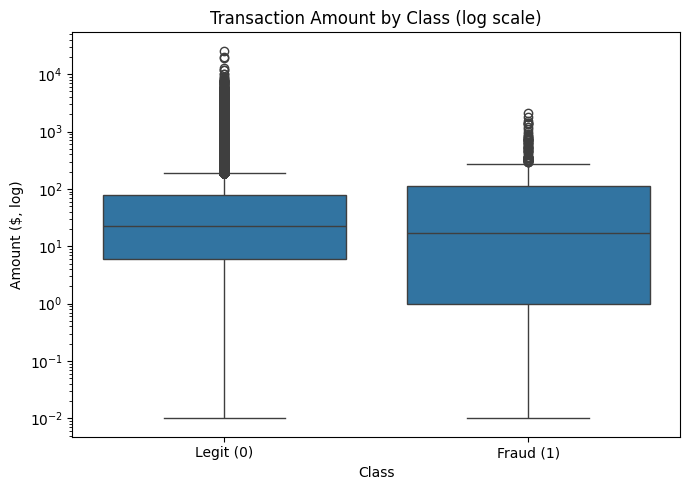

In [124]:
import matplotlib.pyplot as plt
import seaborn as sns

# only need these two columns; Amount=0 rows dropped so log scale behaves
amt = (df.select("Class", "Amount")
         .filter(F.col("Amount") > 0)
         .toPandas())

fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=amt, x="Class", y="Amount", ax=ax)
ax.set_yscale("log")
ax.set_xticklabels(["Legit (0)", "Fraud (1)"])
ax.set_title("Transaction Amount by Class (log scale)")
ax.set_ylabel("Amount ($, log)")
plt.tight_layout()
plt.show()

# Step 2 -- Time based data split
Split data into training and test based on timing of records; we want older records in training. This way we hold out newer records for streaming/test and we avoid any temporal data leakage.

In [125]:
# Compute the 80th percentile of the Time column and use that as our threshold to split on
threshold = df.approxQuantile("Time", [0.8], 0.0)[0]
train_df = df.filter(col("Time") <= threshold_1)   # everything before the test cut
test_df    = df.filter(col("Time") >  threshold_1)

# threshold_2 = train_full.approxQuantile("Time", [0.9], 0.0)[0]
# train_df = train_full.filter(col("Time") <= threshold_2)
# val_df   = train_full.filter(col("Time") >  threshold_2)


# Step 3 -- Class Weighting
Because the classes are so imbalanced, during model training, the model may memorize the class imbalance pattern, rather than truely adjust weights to predict both classes well. In other words, the model may learn to just predict the class that appears more often (legit purchases in this case) and miss a lot of fraudulent cases. In a scenario such as this one, where we are trying to create a model to better predict fraudulent transactions, it would be better to have a higher sensitivity to potential fraudulent purchases, and to have a higher false positive rate rather than a false negative rate (higher recall rather than precision). 

Logistic regression learns by minimizing a loss function — a single number measuring how wrong the model's predicted probabilities are across all training rows. Normally that loss is a plain sum: every row contributes one term, and the optimizer adjusts the model's coefficients to make that total as small as possible.

The weight changes the sum into a weighted sum. Conceptually, each row's error term gets multiplied by its classWeight before everything is added up:

```
total loss = Σ  classWeight_i × (error on row i)
```

So a fraud row with weight ≈0.998 contributes about 580× more to the total loss than a legit row with weight ≈0.0017. The optimizer only cares about shrinking the total, so it's now far more "motivated" to get the heavily-weighted fraud rows right. Being wrong on a fraud case is expensive; being wrong on a legit case is cheap. It's exactly as if you'd duplicated each fraud row hundreds of times so the model couldn't ignore them, except the weight achieves that without actually copying data.


In [126]:
total = train_df.count()
n_fraud = train_df.filter(col('Class') == 1).count()
ratio = n_fraud/total

# create new 'classWeight' column in the Spark training DF for training later
train_weighted = train_df.withColumn(
    "classWeight",
    when(col('Class') == 1, lit(1-ratio)).otherwise(lit(ratio))
)

train_weighted.select("Class", "classWeight").distinct().show()

+-----+--------------------+
|Class|         classWeight|
+-----+--------------------+
|    1|  0.9981698164549739|
|    0|0.001830183545026...|
+-----+--------------------+



# Step 4 -- The pipeline
First we must identify our training feature columns, which in this case are all columns from the raw data except for 'Time' and the 'Class' (the target feature). We then assemble the columns into a vector, and standardize using a standard scalar transformation on the data to avoid scale imbalance during training. Finally we crete our logisticRegression estimator (using the weightCol parameter with our 'classWeight' training data column) and our XGBoost estimator (using the weight_col parameter with our 'classWeight' training data column). 

We then compile every stage into two SparkML Pipelines, one with an XGBoost estimator and another with a Logistic Regression estimator, and then we fit the Pipelines on the training data to get our model pipelines ready for making predictions on new, streamed data.


In [127]:
feature_cols = [f"V{i}" for i in range(1,29)] + ['Amount']
assembler = VectorAssembler(inputCols=feature_cols, outputCol="raw_features")
scalar = StandardScaler(inputCol='raw_features', outputCol='features',
                        withMean=True, withStd=True)

lr = LogisticRegression(
    featuresCol='features',
    labelCol='Class',
    weightCol='classWeight'
)

xgb = SparkXGBClassifier(
    features_col='features',
    label_col='Class',
    weight_col='classWeight',
    missing = 0.0
)

lr_pipeline = Pipeline(stages=[assembler,scalar,lr])
xgb_pipeline = Pipeline(stages=[assembler,scalar,xgb])

lr_model = lr_pipeline.fit(train_weighted)
xgb_model = xgb_pipeline.fit(train_weighted)

2026-06-06 16:24:05,616 INFO XGBoost-PySpark: _fit Running xgboost-3.2.0 on 1 workers with
	booster params: {'objective': 'binary:logistic', 'device': 'cpu', 'nthread': 1}
	train_call_kwargs_params: {'verbose_eval': True, 'num_boost_round': 100}
	dmatrix_kwargs: {'nthread': 1, 'missing': 0.0}
2026-06-06 16:24:07,847 INFO XGBoost-PySpark: _train_booster Training on CPUs 1]
[16:24:08] Task 0 got rank 0
[16:24:09] [0]	training-logloss:0.47364
[16:24:09] [1]	training-logloss:0.34794
[16:24:09] [2]	training-logloss:0.26817
[16:24:09] [3]	training-logloss:0.21476
[16:24:09] [4]	training-logloss:0.17454
[16:24:09] [5]	training-logloss:0.14405
[16:24:09] [6]	training-logloss:0.12055
[16:24:09] [7]	training-logloss:0.10287
[16:24:09] [8]	training-logloss:0.08944
[16:24:09] [9]	training-logloss:0.07863
[16:24:09] [10]	training-logloss:0.07012
[16:24:09] [11]	training-logloss:0.06313
[16:24:09] [12]	training-logloss:0.05752
[16:24:09] [13]	training-logloss:0.05365
[16:24:09] [14]	training-logloss

# Step 5 -- Evaluate on the test set as a batch first (get the headline numbers)
Accuracy is a trap here because of the large class imbalance; we can get good accuracy by just predicting 0 (legit transaction) for every instance in the dataset. Instead, we will lead with PR-AUC and the fraud-class recall and precision instead to better understand model effectiveness.

### 1) Logistic Regression Model Evaluation

In [128]:
preds = lr_model.transform(test_df)

pr_auc = BinaryClassificationEvaluator(
    labelCol="Class", metricName="areaUnderPR").evaluate(preds)

roc_auc = BinaryClassificationEvaluator(
    labelCol="Class", metricName="areaUnderROC").evaluate(preds)

print(f"PR-AUC={pr_auc:.4f}. ROC-AUC={roc_auc:.4f}")
preds.groupBy('Class', 'prediction').count().show()

preds.crosstab("Class", "prediction").show()

PR-AUC=0.7301. ROC-AUC=0.9863
+-----+----------+-----+
|Class|prediction|count|
+-----+----------+-----+
|    0|       0.0|55408|
|    1|       1.0|   68|
|    0|       1.0| 1478|
|    1|       0.0|    7|
+-----+----------+-----+

+----------------+-----+----+
|Class_prediction|  0.0| 1.0|
+----------------+-----+----+
|               0|55408|1478|
|               1|    7|  68|
+----------------+-----+----+



### 2) XGBoost Model Evaluation

In [129]:
preds = xgb_model.transform(test_df)

pr_auc = BinaryClassificationEvaluator(
    labelCol="Class", metricName="areaUnderPR").evaluate(preds)

roc_auc = BinaryClassificationEvaluator(
    labelCol="Class", metricName="areaUnderROC").evaluate(preds)

print(f"PR-AUC={pr_auc:.4f}. ROC-AUC={roc_auc:.4f}")
preds.groupBy('Class', 'prediction').count().show()

preds.crosstab("Class", "prediction").show()

2026-06-06 16:24:13,844 INFO XGBoost-PySpark: predict_udf Do the inference on the CPUs
2026-06-06 16:24:15,152 INFO XGBoost-PySpark: predict_udf Do the inference on the CPUs


PR-AUC=0.7731. ROC-AUC=0.9821


2026-06-06 16:24:15,409 INFO XGBoost-PySpark: predict_udf Do the inference on the CPUs


+-----+----------+-----+
|Class|prediction|count|
+-----+----------+-----+
|    1|       0.0|   15|
|    0|       0.0|56746|
|    1|       1.0|   60|
|    0|       1.0|  140|
+-----+----------+-----+



2026-06-06 16:24:15,666 INFO XGBoost-PySpark: predict_udf Do the inference on the CPUs


+----------------+-----+---+
|Class_prediction|  0.0|1.0|
+----------------+-----+---+
|               0|56746|140|
|               1|   15| 60|
+----------------+-----+---+



2026-06-06 16:24:15,980 INFO XGBoost-PySpark: predict_udf Do the inference on the CPUs


The XGBoost model outperformed the lr model by 4% in the PR-AUC metric (73.01% for LR and 77.31% for XGBoost). This is the model we will save and use for the streaming data.

# Step 6 -- Save the Fitted Pipeline

The XGBoost model outperformed the lr model by 4% in the PR-AUC metric (73.01% for LR and 77.31% for XGBoost). This is the model we will save and use for the streaming data.

In [130]:
xgb_model.write().overwrite().save("fraud_pipeline_model")
lr_model.write().overwrite().save("fraud_pipeline_model_lr")

# Step 7 -- Stage the Stream (split the test set into ordered files)

Write the test transactions, in time order, to several files in one directory -- one file = one trigger. 

In [ ]:
import os

# Pull the test set to the driver as a pandas DataFrame, ordered by Time so the
# chunks below come out as contiguous time-slices (preserves the "transactions
# arrive in order" framing)
test_pd = test_df.orderBy("Time").toPandas()

# Create the output folder for the stream files; exist_ok=True avoids an error
# if it's already there (e.g. on a re-run).
os.makedirs("./data/stream_input", exist_ok=True)

# Number of files to split the test set into. each one becomes a single
# streaming trigger (one file read per micro-batch).
n_chunks = 10

# Rows per chunk, using ceiling division so the rows divide evenly into 10 files.
# -(-a // b) rounds UP (plain // rounds down), guaranteeing all rows are covered
# rather than leaving a remainder unwritten.
chunk_size = -(-len(test_pd) // n_chunks)

# Walk through the DataFrame in equal-sized, time-ordered slices.
for i in range(n_chunks):
    # iloc[start:stop] returns a DataFrame slice; the last chunk just takes
    # whatever rows remain. Slicing past the end is safe (returns fewer rows).
    chunk = test_pd.iloc[i * chunk_size : (i + 1) * chunk_size]

    # If rounding produced an empty trailing slice, skip it so we don't write
    # an empty file (which would create a no-op trigger when streaming).
    if chunk.empty:
        continue

    # Write each chunk as its own CSV, zero-padded (part_00, part_01, …) so the
    # filenames sort in order. index=False keeps the pandas row index out of the file.
    chunk.to_csv(f"./data/stream_input/part_{i:02d}.csv", index=False)

# Step 8 -- Stream it through the saved model

Filestreaming needs an explicit schema; we will reuse the batch one

foreachBatch is a clean way to both transform and evaluate model performance per trigger

In [137]:
model = PipelineModel.load("fraud_pipeline_model")
schema = df.schema

# create the streaming data frame
# make sure we are streaming from the correct directory
# setting maxFilesPerTrigger to 1 guarantees we stream one file at a time
# we also set schema to the original DF schema from earlier
stream_df = (spark.readStream
             .schema(schema)
             .option("maxFilesPerTrigger", 1)
             .csv("./data/stream_input", header=True))

agg = [] # accumulate confusion counts across micro-batches (single streaming files)

def process_batch(batch_df, batch_id):
    p = model.transform(batch_df)
    tp = p.filter((col("Class")==1) & (col("prediction")==1)).count()
    fp = p.filter((col("Class")==0) & (col("prediction")==1)).count()
    fn = p.filter((col("Class")==1) & (col("prediction")==0)).count()
    tn = p.filter((col("Class")==0) & (col("prediction")==0)).count()

    pr_auc = BinaryClassificationEvaluator(
    labelCol="Class", metricName="areaUnderPR").evaluate(p)

    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall    = tp / (tp + fn) if (tp + fn) else 0.0

    agg.append({'Batch ID': batch_id, 'PR_AUC': round(pr_auc,2), 'precision': round(precision,2), 'recall': round(recall,2)})




In [138]:
query = (stream_df.writeStream
         .foreachBatch(process_batch)
         .trigger(availableNow=True)
         .start())
query.awaitTermination()

26/06/06 16:25:59 WARN ResolveWriteToStream: Temporary checkpoint location created which is deleted normally when the query didn't fail: /private/var/folders/xm/n3hfmgys1fbbwsdf1jv6j7q00000gn/T/temporary-a4226248-5b32-4b65-a627-905daaf7c53f. If it's required to delete it under any circumstances, please set spark.sql.streaming.forceDeleteTempCheckpointLocation to true. Important to know deleting temp checkpoint folder is best effort.
26/06/06 16:25:59 WARN ResolveWriteToStream: spark.sql.adaptive.enabled is not supported in streaming DataFrames/Datasets and will be disabled.
2026-06-06 16:26:00,921 INFO XGBoost-PySpark: predict_udf Do the inference on the CPUs
2026-06-06 16:26:00,983 INFO XGBoost-PySpark: predict_udf Do the inference on the CPUs
2026-06-06 16:26:01,058 INFO XGBoost-PySpark: predict_udf Do the inference on the CPUs
2026-06-06 16:26:01,116 INFO XGBoost-PySpark: predict_udf Do the inference on the CPUs
2026-06-06 16:26:01,184 INFO XGBoost-PySpark: predict_udf Do the infere

In [139]:
for i in agg:
    print(i)

{'Batch ID': 0, 'PR_AUC': 0.51, 'precision': 0.31, 'recall': 0.83}
{'Batch ID': 1, 'PR_AUC': 0.93, 'precision': 0.44, 'recall': 0.92}
{'Batch ID': 2, 'PR_AUC': 0.93, 'precision': 0.58, 'recall': 0.92}
{'Batch ID': 3, 'PR_AUC': 0.72, 'precision': 0.38, 'recall': 0.73}
{'Batch ID': 4, 'PR_AUC': 0.7, 'precision': 0.31, 'recall': 0.75}
{'Batch ID': 5, 'PR_AUC': 0.8, 'precision': 0.4, 'recall': 1.0}
{'Batch ID': 6, 'PR_AUC': 0.83, 'precision': 0.25, 'recall': 0.83}
{'Batch ID': 7, 'PR_AUC': 0.13, 'precision': 0.06, 'recall': 0.5}
{'Batch ID': 8, 'PR_AUC': 0.18, 'precision': 0.08, 'recall': 0.4}
{'Batch ID': 9, 'PR_AUC': 0.64, 'precision': 0.22, 'recall': 0.8}
